In [15]:
import numpy as np
import pandas as pd
import zarr
import torch
import math
from datetime import datetime, timedelta
import statsmodels.api as sm
import os
import gc
from datetime import datetime, date, timedelta 
import re
import shutil


In [16]:
# --- Load Zarr dataset ---
INPUT_ZARR = "/data_2/scratch/francesco/zarr_demo_daily/"
dst = "/data_2/scratch/francesco/zarr_demo_daily_output"
shutil.copytree(INPUT_ZARR, dst,  dirs_exist_ok=True)

ds = zarr.open_group(INPUT_ZARR, mode="r")
ds_out = zarr.open_group(dst, mode="r+") 

# read the copyed value (at this stage are identical to the original ones)
ndvi_zarr = ds_out["ndvi"]
dates_zarr = ds_out["dates"]
params_lower_zarr = ds_out["params"]["params_lower"]
params_upper_zarr = ds_out["params"]["params_upper"]
last_dates_zarr = ds_out["last_dates"]


# --- Helper: decode and parse Zarr date entries ---
def _parse_zarr_date(d_val):
    if isinstance(d_val, (bytes, np.bytes_)):
        return pd.to_datetime(d_val.decode("utf-8"), errors="coerce")
    else:
        s = str(d_val)
        if s.startswith("np.bytes_("):
            m = re.search(r"b['\"]([^'\"]+)['\"]", s)
            if m:
                s = m.group(1)
        return pd.to_datetime(s, errors="coerce")

# --- Extract all valid dates from Zarr ---
dates = []
for i in range(dates_zarr.shape[0]):
    d_arr = dates_zarr.get_basic_selection((i,))
    d_val = d_arr[()] if isinstance(d_arr, np.ndarray) and d_arr.shape == () else d_arr[0]
    d_dt = _parse_zarr_date(d_val)
    if pd.notna(d_dt):
        dates.append(d_dt)

dates = sorted(list(set(dates)))
if not dates:
    raise ValueError("No valid dates found in the Zarr dataset.")

ds_out.tree()

/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:99: UserWarning: The codec `vlen-bytes` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:99: UserWarning: The codec `vlen-bytes` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)
/home/francesco/miniconda3/envs/ndvi/lib/python3.11/site-packages/zarr/codecs/vlen_utf8.py:99: UserWarning: The codec `vlen-bytes` is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  return cls(**configuration_parsed)


/
├── counter (3073,) int16
├── dates (3073,) object
├── last_dates (8, 1000014) object
├── ndvi (3073, 1000014) int16
└── params
    ├── params_lower (1000014, 6) float32
    └── params_upper (1000014, 6) float32

In [ ]:
# --- Double logistic function ---
def double_logistic_function(t, params):
    sos, mat_minus_sos, sen, eos_minus_sen, M, m = params
    mat_minus_sos = np.log1p(np.exp(mat_minus_sos)) 
    eos_minus_sen = np.log1p(np.exp(eos_minus_sen))
    
    sigmoid_sos_mat = 1 / (1 + np.exp(-2 * (2*sos + mat_minus_sos - 2*t) / (mat_minus_sos + 1e-10)))
    sigmoid_sen_eos = 1 / (1 + np.exp(-2 * (2*sen + eos_minus_sen - 2*t) / (eos_minus_sen + 1e-10)))
    
    return (M - m) * (sigmoid_sos_mat - sigmoid_sen_eos) + m

def calculate_median(doy, params_lower, params_upper):

    T_SCALE = 1.0 / 365.0

    t = torch.tensor(doy * T_SCALE, dtype=torch.float32)
    lower = double_logistic_function(t, params_lower)
    upper = double_logistic_function(t, params_upper)

    return 0.5 * (upper + lower)

def estimate_ndvi(days_diff, median, delta_prev):
    decrease_factor = math.exp(-math.log(2) * (days_diff / 15))
    return median + delta_prev * decrease_factor

def unwrap_scalar(x):
    """Recursively unwrap 0-d arrays until we get a real scalar."""
    while isinstance(x, np.ndarray) and x.shape == ():
        x = x.item()
    return x

def zarr_date_to_date(zarr_date):
    zarr_date = unwrap_scalar(zarr_date)

    if isinstance(zarr_date, bytes):
        return datetime.strptime(zarr_date.decode("utf-8"), "%Y-%m-%d").date()
    elif isinstance(zarr_date, np.datetime64):
        return zarr_date.astype('M8[D]').astype(datetime).date()
    elif isinstance(zarr_date, datetime):
        return zarr_date.date()
    elif isinstance(zarr_date, date):
        return zarr_date
    else:
        raise TypeError(f"Unknown date type: {type(zarr_date)}")



# --- Main function ---
def print_ndvi(day, pixel_idx):

    base_date = zarr_date_to_date(dates[0])
    date_index = (day - base_date).days
    ndvi_val = ndvi_zarr[date_index, pixel_idx]

    # Read last date from Zarr
    last_date_raw = last_dates_zarr[6, pixel_idx]
    last_date = zarr_date_to_date(last_date_raw)

    params_lower = params_lower_zarr[pixel_idx]
    params_upper = params_upper_zarr[pixel_idx]

    doy = day.timetuple().tm_yday

    if last_date !=  date(1900, 1, 1):
        last_doy = last_date.timetuple().tm_yday
        days_diff = (day - last_date).days

        last_idx = (last_date - base_date).days

        last_ndvi = ndvi_zarr[last_idx, pixel_idx]
        last_ndvi = last_ndvi / 10000.0
        delta_prev = last_ndvi - calculate_median(last_doy, params_lower, params_upper)

    ndvi_val = ndvi_val / 10000.0

    if ndvi_val >= 1 or ndvi_val <= 0:
        ndvi_val = np.nan

        # Write last date back to Zarr
        if last_date !=  date(1900, 1, 1):
            estimation = estimate_ndvi(days_diff, calculate_median(doy, params_lower, params_upper), delta_prev)
            ndvi_zarr[date_index, pixel_idx] = np.int16(estimation * 10000)

    else:
        
        last_dates_zarr[6:7, pixel_idx] = np.array([day.strftime("%Y-%m-%d").encode("utf-8")], dtype=object)

    #print(f"Pixel {pixel_idx:>4} | {day} | DOY={doy} | NDVI={ndvi_val:.4f} | last date={last_date}")

# --- Example run ---
for i in range(3000):
    day = zarr_date_to_date(dates[i])
    print_ndvi(day, 42)


93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112


/tmp/ipykernel_414194/2215817050.py:7: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sigmoid_sos_mat = 1 / (1 + np.exp(-2 * (2*sos + mat_minus_sos - 2*t) / (mat_minus_sos + 1e-10)))
/tmp/ipykernel_414194/2215817050.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  sigmoid_sen_eos = 1 / (1 + np.exp(-2 * (2*sen + eos_minus_sen - 2*t) / (eos_minus_sen + 1e-10)))


113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277
278
279
280
281
282
283
284
285
286
287
288
289
290
291
292
293
294
295
296
297
298
299
300
301
302
303
304
305
306
307
308
309
310
311
312
313
314
315
316
317
318
319
320
321
322
323
324
325
326
327
328
329
330
331
332
333
334
335
336
337
338
339
340
341
342
343
344
345
346
347
348
349
350
351
352
353
354
355
356
357
358
359
360
361
362


KeyboardInterrupt: 

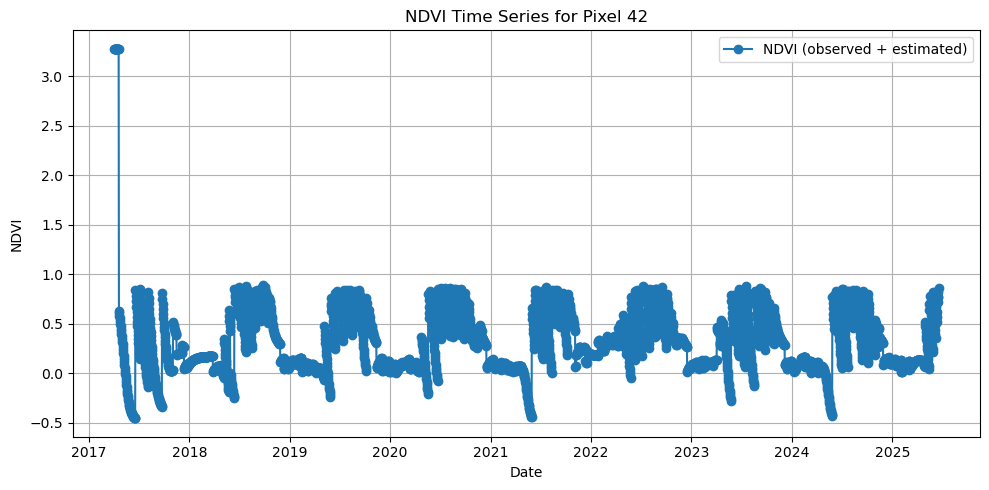

In [ ]:
import matplotlib.pyplot as plt

# Reopen the NDVI zarr group
root = zarr.open("/data_2/scratch/francesco/zarr_demo_daily_output", mode="r")

# Access the actual NDVI array
ndvi_arr = root["ndvi"]

# Extract NDVI time series
base_date = zarr_date_to_date(dates[0])
date_list = [zarr_date_to_date(d) for d in dates[:3000]]
ndvi_series = ndvi_arr[:3000, 42] / 10000.0

# Plot
plt.figure(figsize=(10, 5))
plt.plot(date_list, ndvi_series, marker="o", label="NDVI (observed + estimated)")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.title(f"NDVI Time Series for Pixel 42")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import zarr
import math
from datetime import datetime, date, timedelta
import matplotlib.pyplot as plt

# --- Double logistic function ---
def double_logistic_function(t, params):
    sos, mat_minus_sos, sen, eos_minus_sen, M, m = params
    mat_minus_sos = np.log1p(np.exp(mat_minus_sos))
    eos_minus_sen = np.log1p(np.exp(eos_minus_sen))
    sigmoid_sos_mat = 1 / (1 + np.exp(-2 * (2*sos + mat_minus_sos - 2*t) / (mat_minus_sos + 1e-10)))
    sigmoid_sen_eos = 1 / (1 + np.exp(-2 * (2*sen + eos_minus_sen - 2*t) / (eos_minus_sen + 1e-10)))
    return (M - m) * (sigmoid_sos_mat - sigmoid_sen_eos) + m

def calculate_median(doy, params_lower, params_upper):
    t = doy / 365.0
    lower = double_logistic_function(t, params_lower)
    upper = double_logistic_function(t, params_upper)
    return 0.5 * (upper + lower)

def estimate_ndvi(days_diff, median, delta_prev):
    decrease_factor = math.exp(-math.log(2) * (days_diff / 45))
    return median + delta_prev * decrease_factor

def unwrap_scalar(x):
    while isinstance(x, np.ndarray) and x.shape == ():
        x = x.item()
    return x

def zarr_date_to_date(zarr_date):
    zarr_date = unwrap_scalar(zarr_date)
    if isinstance(zarr_date, bytes):
        return datetime.strptime(zarr_date.decode("utf-8"), "%Y-%m-%d").date()
    elif isinstance(zarr_date, np.datetime64):
        return zarr_date.astype("M8[D]").astype(datetime).date()
    elif isinstance(zarr_date, datetime):
        return zarr_date.date()
    elif isinstance(zarr_date, date):
        return zarr_date
    else:
        raise TypeError(f"Unknown date type: {type(zarr_date)}")


# --- Main function (no RAM storage) ---
def process_pixel(pixel_idx):
    base_date = zarr_date_to_date(dates[0])
    params_lower = params_lower_zarr[pixel_idx]
    params_upper = params_upper_zarr[pixel_idx]

    for i in range(len(dates)):
        day = zarr_date_to_date(dates[i])
        doy = day.timetuple().tm_yday
        ndvi_val = ndvi_zarr[i, pixel_idx] / 10000.0

        last_date_raw = last_dates_zarr[6, pixel_idx]
        last_date = zarr_date_to_date(last_date_raw)

        if last_date != date(1900, 1, 1):
            last_doy = last_date.timetuple().tm_yday
            days_diff = (day - last_date).days
            last_idx = (last_date - base_date).days

            last_ndvi = ndvi_zarr[last_idx, pixel_idx] / 10000.0
            delta_prev = last_ndvi - calculate_median(last_doy, params_lower, params_upper)
        else:
            delta_prev = 0.0
            days_diff = 0

        if ndvi_val >= 1 or ndvi_val <= 0:
            ndvi_val = np.nan
            if last_date != date(1900, 1, 1):
                est = estimate_ndvi(days_diff, calculate_median(doy, params_lower, params_upper), delta_prev)
                est = np.clip(est, 0, 1)
                ndvi_zarr[i, pixel_idx] = np.int16(est * 10000)
        else:
            last_dates_zarr[6:7, pixel_idx] = np.array(
                [day.strftime("%Y-%m-%d").encode("utf-8")], dtype=object
            )

# --- Run the fill for a single pixel ---
pixel = 42
for i in range(1000):
    day = zarr_date_to_date(dates[i])
    process_pixel(pixel)

# --- Reopen from disk for plotting ---
ndvi_zarr_reopened = zarr.open("/data_2/scratch/francesco/zarr_demo_daily_output", mode="r")

date_list = [zarr_date_to_date(d) for d in dates[:1000]]
params_lower = params_lower_zarr[pixel]
params_upper = params_upper_zarr[pixel]

ndvi_series = ndvi_zarr_reopened[:1000, pixel] / 10000.0
doy_list = np.array([d.timetuple().tm_yday for d in date_list])
t_list = doy_list / 365.0
lower_curve = np.array([double_logistic_function(t, params_lower) for t in t_list])
upper_curve = np.array([double_logistic_function(t, params_upper) for t in t_list])

# --- Plot everything ---
plt.figure(figsize=(10, 5))
plt.plot(date_list, ndvi_series, "o-", label="NDVI (observed + estimated)")
plt.plot(date_list, lower_curve, "--", label="Lower logistic bound")
plt.plot(date_list, upper_curve, "--", label="Upper logistic bound")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.title(f"NDVI Time Series for Pixel {pixel}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
# --- Reopen from disk for plotting ---
ndvi_zarr_reopened = zarr.open("/data_2/scratch/francesco/zarr_demo_daily_output", mode="r")

date_list = [zarr_date_to_date(d) for d in dates[:1000]]
params_lower = params_lower_zarr[pixel]
params_upper = params_upper_zarr[pixel]

ndvi_series = ndvi_zarr_reopened[:1000, pixel] / 10000.0
doy_list = np.array([d.timetuple().tm_yday for d in date_list])
t_list = doy_list / 365.0
lower_curve = np.array([double_logistic_function(t, params_lower) for t in t_list])
upper_curve = np.array([double_logistic_function(t, params_upper) for t in t_list])

# --- Plot everything ---
plt.figure(figsize=(10, 5))
plt.plot(date_list, lower_curve, "--", label="Lower")
plt.plot(date_list, upper_curve, "--", label="Upper")
plt.xlabel("Date")
plt.ylabel("NDVI")
plt.title(f"NDVI Time Series for Pixel {pixel}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
import zarr
ds = zarr.open_group("/data_2/scratch/francesco/zarr_demo_daily_output", mode="r")
arr = ds["last_dates"]
pixel_idx = 123456  # use one you know your script uses
print("max index:", arr.shape[1]-1)
print("pixel_idx:", pixel_idx)
print("value:", arr[6, pixel_idx])


max index: 1000013
pixel_idx: 123456
value: np.bytes_(b'1900-01-01')


In [2]:
arr = ds["last_dates"]
print("compressor:", arr.compressor)           # shows compressor object or None
print("filters:", arr.filters)
print("dtype:", arr.dtype)
print("chunks:", arr.chunks)
print("zarr_version:", getattr(arr, 'zarr_version', 'n/a'))

/tmp/ipykernel_1398896/2654491486.py:2: DeprecationWarning: Use Array.compressors instead.
  print("compressor:", arr.compressor)           # shows compressor object or None


TypeError: `compressor` is not available for Zarr format 3 arrays.